In [4]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence
from sim_library.plotting import plot_state_trajectories, plot_bloch
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt


### NOT Gate

In [5]:
p_min = -1
p_max = 5
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 100

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 0
initial_state[1] = 1
initial_state[2] = 0
initial_state[3] = 1
initial_state[4] = 0
initial_state[5] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

not_gate = PulseSequence()

freevolve_halfpi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
pi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

not_gate.add_pulses([freevolve_halfpi, pi_pulse, freevolve_halfpi])

wave_func, times = simulate_pulses_single_atom(pulse_seq= not_gate, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

print(np.round(np.square(np.abs(wave_func[-1,:])), 5))



[0.        +0.j 0.57735027+0.j 0.        +0.j 0.57735027+0.j
 0.        +0.j 0.57735027+0.j 0.        +0.j]
[0.00000000e+00+0.00000000e+00j 2.25167107e-15+0.00000000e+00j
 5.77350269e-01-9.16389650e-06j 8.57758250e-05+3.54097668e-03j
 5.77094690e-01-1.68079140e-02j 6.17208915e-04+7.05693810e-03j
 5.74591934e-01-5.59219270e-02j]
[0.0000e+00 0.0000e+00 3.3333e-01 1.0000e-05 3.3332e-01 5.0000e-05
 3.3328e-01]


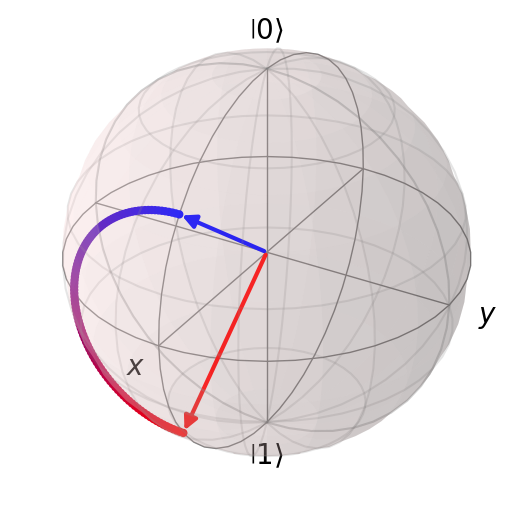

In [8]:
plot_bloch(wave_func=wave_func)

In [7]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 100

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 2
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

not_gate = PulseSequence()

freevolve_halfpi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
pi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

not_gate.add_pulses([pi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= not_gate, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

print(len(wave_func))

[0.89442719+0.j 0.4472136 +0.j]
[ 3.42434414e-15-0.4472136j  -1.71043735e-15-0.89442719j]
101


### CP1

In [101]:
# Inverts phase if state = 0

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 50

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

cpone = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time) #pi
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

cpone.add_pulses([freevolve_pi])

wave_func, times = simulate_pulses_single_atom(pulse_seq= cpone, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

[0.70710678+0.j 0.70710678+0.j]
[ 0.70710678+0.00000000e+00j -0.70710678+2.24468705e-05j]


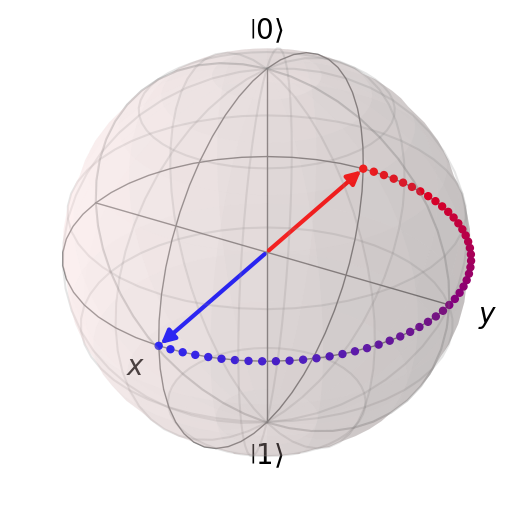

In [102]:
plot_bloch(wave_func=wave_func)

### Hadamard

In [135]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 50

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = -5
initial_state[1] = 2j
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

hadamard = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time) #pi
halfpi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

hadamard.add_pulses([freevolve_pi, halfpi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= hadamard, basis= basis, initial_state=initial_state, d_shift=0)

beep = initial_state.reshape(2,1)
hadamardmat = (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
simmed = np.dot(hadamardmat, beep) 

print("sim:",wave_func[-1,:])
print("target:",simmed.transpose()[0])



[-0.92847669+0.j          0.        +0.37139068j]
sim: [-0.65652383+0.26261287j -0.6565405 -0.26261287j]
target: [-0.65653216+0.26261287j -0.65653216-0.26261287j]


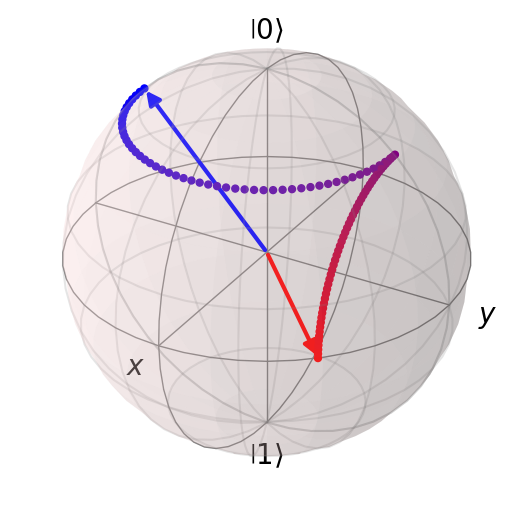

In [136]:
plot_bloch(wave_func=wave_func)

In [40]:
print(omega_eg)
print(dR)

19074060415.5
96368.27489031358


In [92]:
print(np.exp(1j*pi/2))

(6.123233995736766e-17+1j)
